# Kangaroo Island (Australia) Bushfires (2019-2020)

## Notebook 3: Application of AI and Machine Learning to assess Bushfires

This Notebook:
1. Extracts pixels from Figures generated in Notebook 1 for AI Training
2. Applies Supervised Learning (Random Forests) and Unsupervised Learning (K-Means Clustering) algorithms to generate burn severity maps
3. Evaluates and comapares accuracy of both algorithms
4. Summarises Environmental Impact of operating the notebook

## Step 1: Connecting Notebook with Google Drive and Setup Emissions Tracker

In [3]:
import logging
import os
!pip install -q codecarbon

# set up emissions tracker
os.environ["CODECARBON_LOG_LEVEL"] = "error"
logging.getLogger("codecarbon").setLevel(logging.ERROR)

from codecarbon import EmissionsTracker
tracker = EmissionsTracker(save_to_file=False)
tracker.start()

import rasterio
import numpy as np
import pandas as pd
from google.colab import drive

# connect folders
drive.mount('/content/drive', force_remount=True)
base_path = '/content/drive/MyDrive/AI4EO/AI4EO_Main_Project/'
data_path = os.path.join(base_path, 'data')



Mounted at /content/drive


## Step 2: Extract Pixels from Generated Images for Training AI

In [4]:
# define paths
post_fire_path = os.path.join(data_path, 'Kangaroo_Island_Post_Fire.tif')
pre_fire_path = os.path.join(data_path, 'Kangaroo_Island_Pre_Fire.tif')

# extract values of pixels
with rasterio.open(post_fire_path) as src:
    # Post-fire bands: B4(Red), B3(Green), B2(Blue), B8(NIR)
    post_red = src.read(1).astype('float32').flatten()
    post_green = src.read(2).astype('float32').flatten()
    post_blue = src.read(3).astype('float32').flatten()
    post_nir = src.read(4).astype('float32').flatten()

with rasterio.open(pre_fire_path) as src_pre:

    pre_red = src_pre.read(1).astype('float32').flatten()
    pre_nir = src_pre.read(4).astype('float32').flatten()

# labels using NDVI
ndvi_pre = (pre_nir - pre_red) / (pre_nir + pre_red + 1e-6)
ndvi_post = (post_nir - post_red) / (post_nir + post_red + 1e-6)
d_ndvi = ndvi_pre - ndvi_post

df = pd.DataFrame({
    'Red': post_red,
    'Green': post_green,
    'Blue': post_blue,
    'NIR': post_nir,
    'Label': np.where(d_ndvi > 0.3, 1, 0) # 1 = Burned, 0 = Healthy
})

# remove ocean pixels
df = df[df['NIR'] > 200].dropna()


## Step 3: Apply Random Forests Machine Learning Algorithm on extracted pixels

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# pick 1 million pixels
df_sample = df.sample(n=1000000, random_state=42)

X = df_sample[['Red', 'Green', 'Blue', 'NIR']]
y = df_sample['Label']

#  Split pixels for Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"New Study Guide: {len(X_train):,} pixels (Sampled for speed)")

model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training the AI (This takes a while)")
model.fit(X_train, y_train)



New Study Guide: 800,000 pixels (Sampled for speed)
Training the AI (This takes a while)


RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

## Step 4: Supervised Learning (Random Forest) Results visualised in Confusion Matrix

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)

print(" AI PERFORMANCE REPORT")
print(classification_report(y_test, y_pred))

# make confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

 AI PERFORMANCE REPORT
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    153230
           1       0.89      0.91      0.90     46770

    accuracy                           0.95    200000
   macro avg       0.93      0.94      0.93    200000
weighted avg       0.95      0.95      0.95    200000

Confusion Matrix:
[[148047   5183]
 [  4221  42549]]


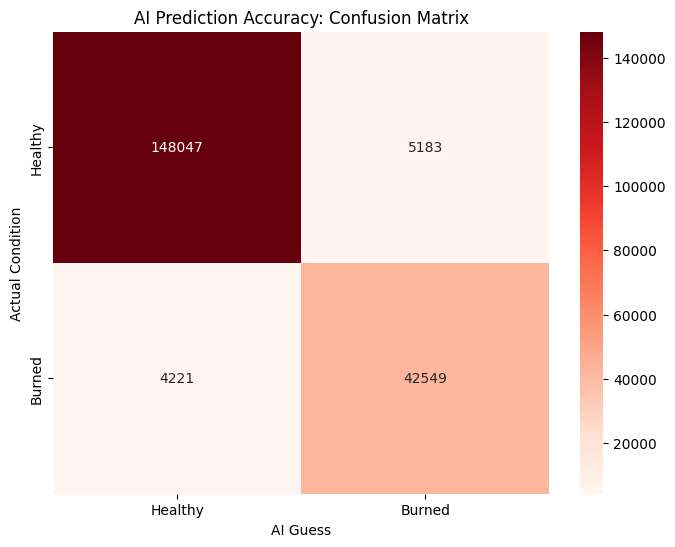

Matrix saved to: /content/drive/MyDrive/AI4EO/AI4EO_Main_Project/figures/ai_confusion_matrix.png


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Burned'],
            yticklabels=['Healthy', 'Burned'])

plt.title('AI Prediction Accuracy: Confusion Matrix')
plt.ylabel('Actual Condition')
plt.xlabel('AI Guess')
figures_path = os.path.join(base_path, 'figures')

# save figure
save_path = os.path.join(figures_path, 'ai_confusion_matrix.png')
plt.savefig(save_path)
plt.show()

print(f"Matrix saved to: {save_path}")

## Step 5: Scaling AI Training for Generating Map

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)


RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

##Step 6: Assess Importance of data used in AI Training

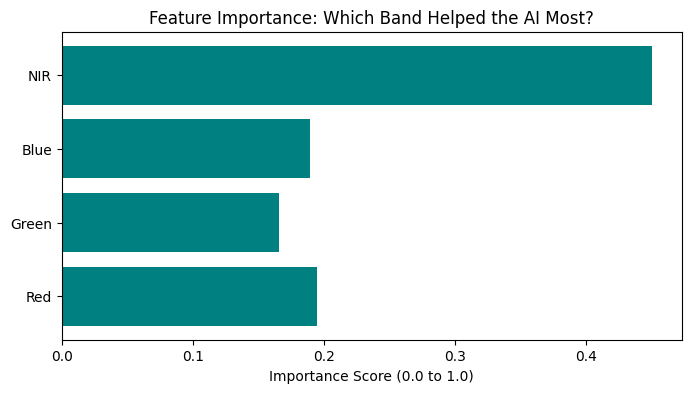

In [13]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feature_names = ['Red', 'Green', 'Blue', 'NIR']

# importance of each band in training
plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='teal')
plt.xlabel('Importance Score (0.0 to 1.0)')
plt.title('Feature Importance: Which Band Helped the AI Most?')

# save figure
plt.savefig(os.path.join(figures_path, 'ai_feature_importance.png'))
plt.show()

## Step 7: Generate Post-Fire Map from Random Forest Trained AI

The AI is mapping the entire island...


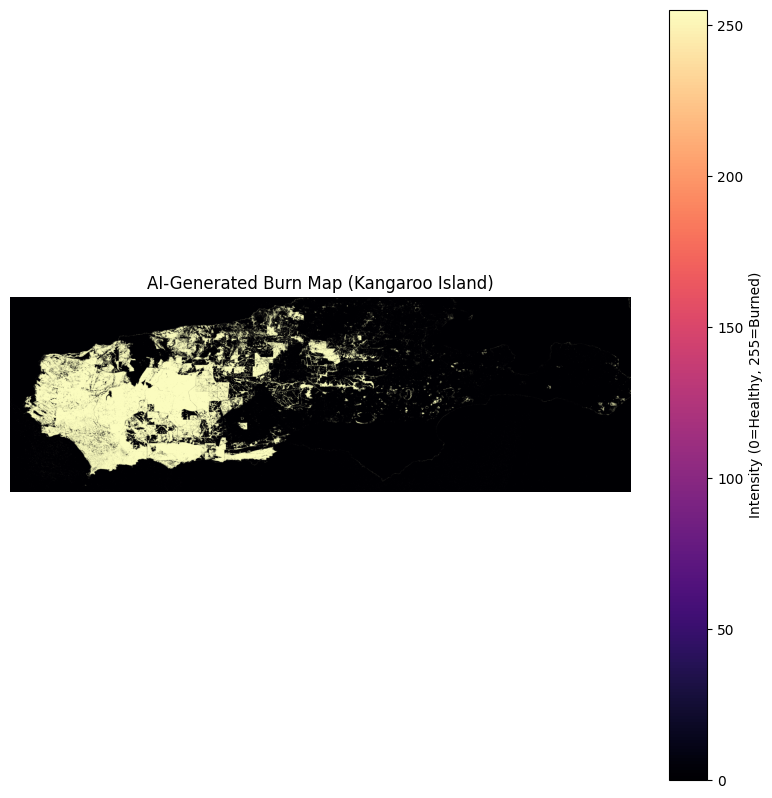

In [16]:
with rasterio.open(post_fire_path) as src:
    full_img = src.read([1, 2, 3, 4]).astype('float32')
    profile = src.profile
full_img_flattened = full_img.transpose(1, 2, 0).reshape(-1, 4)
results_path = os.path.join(base_path, 'results')

full_img_df = pd.DataFrame(full_img_flattened, columns=['Red', 'Green', 'Blue', 'NIR'])

full_img_scaled = scaler.transform(full_img_df)
print("The AI is mapping the entire island...")
full_prediction = model.predict(full_img_scaled)

visible_map = (full_prediction * 255).reshape(full_img.shape[1], full_img.shape[2]).astype('uint8')

# save map
profile.update(count=1, dtype='uint8', nodata=0)
output_map_path = os.path.join(results_path, 'AI_Wildfire_Burn_Map.tif')
with rasterio.open(output_map_path, 'w', **profile) as dst:
    dst.write(visible_map, 1)

# display map
plt.figure(figsize=(10, 10))
plt.imshow(visible_map, cmap='magma') # 'magma' gives a high-contrast scientific look
plt.title('AI-Generated Burn Map (Kangaroo Island)')
plt.colorbar(label='Intensity (0=Healthy, 255=Burned)')
plt.axis('off')
plt.show()


## Step 8: Unsupervised Learning (K-Means Clustering) Generated Map

Running K-Means clustering on valid pixels...


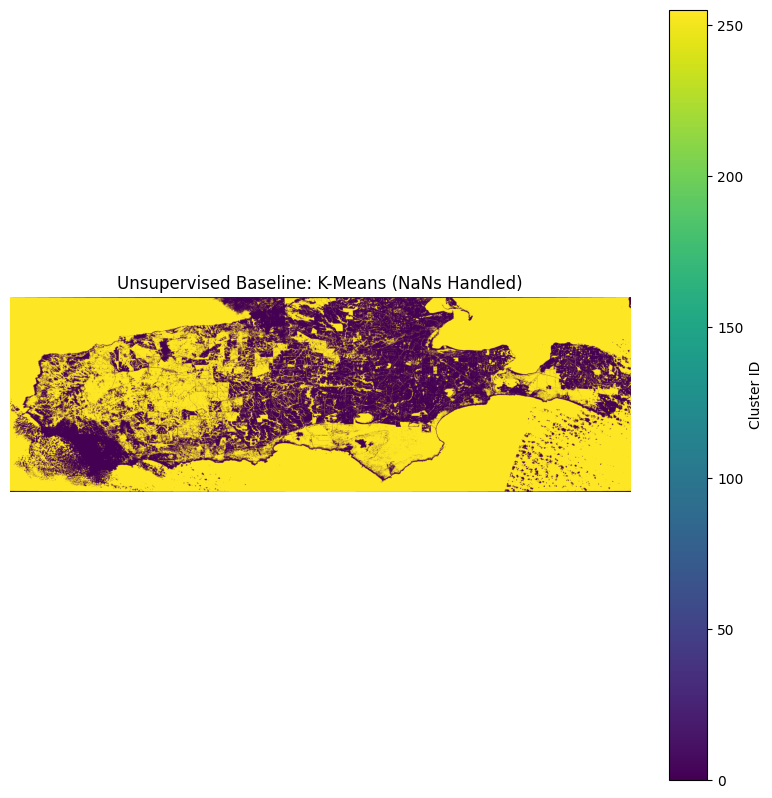

In [18]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
mask = ~np.any(np.isnan(full_img_scaled), axis=1)

kmeans_predictions = np.zeros(full_img_scaled.shape[0], dtype=np.uint8)

# k means clustering
print("Running K-Means clustering on valid pixels...")
valid_predictions = kmeans.fit_predict(full_img_scaled[mask])

kmeans_predictions[mask] = valid_predictions

# show map
kmeans_map = (kmeans_predictions * 255).reshape(full_img.shape[1], full_img.shape[2]).astype('uint8')

plt.figure(figsize=(10, 10))
plt.imshow(kmeans_map, cmap='viridis')
plt.title('Unsupervised Baseline: K-Means (NaNs Handled)')
plt.colorbar(label='Cluster ID')
plt.axis('off')
plt.show()


## Step 9: Comparing Random Forest and K-Means Clustering Results

In [19]:
import pandas as pd

rf_burned_pixels = np.sum(visible_map == 255)
km_burned_pixels = np.sum(kmeans_map == 255)

# calculate differnce
pixel_diff = rf_burned_pixels - km_burned_pixels
percent_diff = (pixel_diff / rf_burned_pixels) * 100

# comparsion table
comparison_data = {
    'Metric': ['Burned Pixels (Count)', 'Estimated Area (Pixels)'],
    'Random Forest (Supervised)': [rf_burned_pixels, rf_burned_pixels],
    'K-Means (Unsupervised)': [km_burned_pixels, km_burned_pixels],
    'Difference': [pixel_diff, f"{percent_diff:.2f}%"]
}

comparison_df = pd.DataFrame(comparison_data)

# 4. Display the table
print("--- MODEL COMPARISON: BURN AREA ESTIMATES ---")
display(comparison_df)

# 5. Save the table to your results folder
comparison_df.to_csv(os.path.join(results_path, 'model_comparison_area.csv'), index=False)

--- MODEL COMPARISON: BURN AREA ESTIMATES ---


,Metric,Random Forest (Supervised),K-Means (Unsupervised),Difference
0,Burned Pixels (Count),4151251,16300770,-12149519
1,Estimated Area (Pixels),4151251,16300770,-292.67%


## Step 10: Evaluating Accuracy of Trained AI

In [20]:
from sklearn.metrics import cohen_kappa_score
kappa_rf = cohen_kappa_score(y_test, y_pred)

# results

print(f"COHEN’S KAPPA SCORE: {kappa_rf:.4f}")


if kappa_rf > 0.80:
    print("Interpretation: Excellent reliability. The AI's mapping is highly consistent.")
elif kappa_rf > 0.60:
    print("Interpretation: Substantial reliability. The AI is significantly better than random chance.")
else:
    print("Interpretation: Moderate reliability. Consider adding more training points.")

COHEN’S KAPPA SCORE: 0.8697
Interpretation: Excellent reliability. The AI's mapping is highly consistent.


## Step 11: Visualise Pre-Fire, Post-Fire and AI Generated Maps

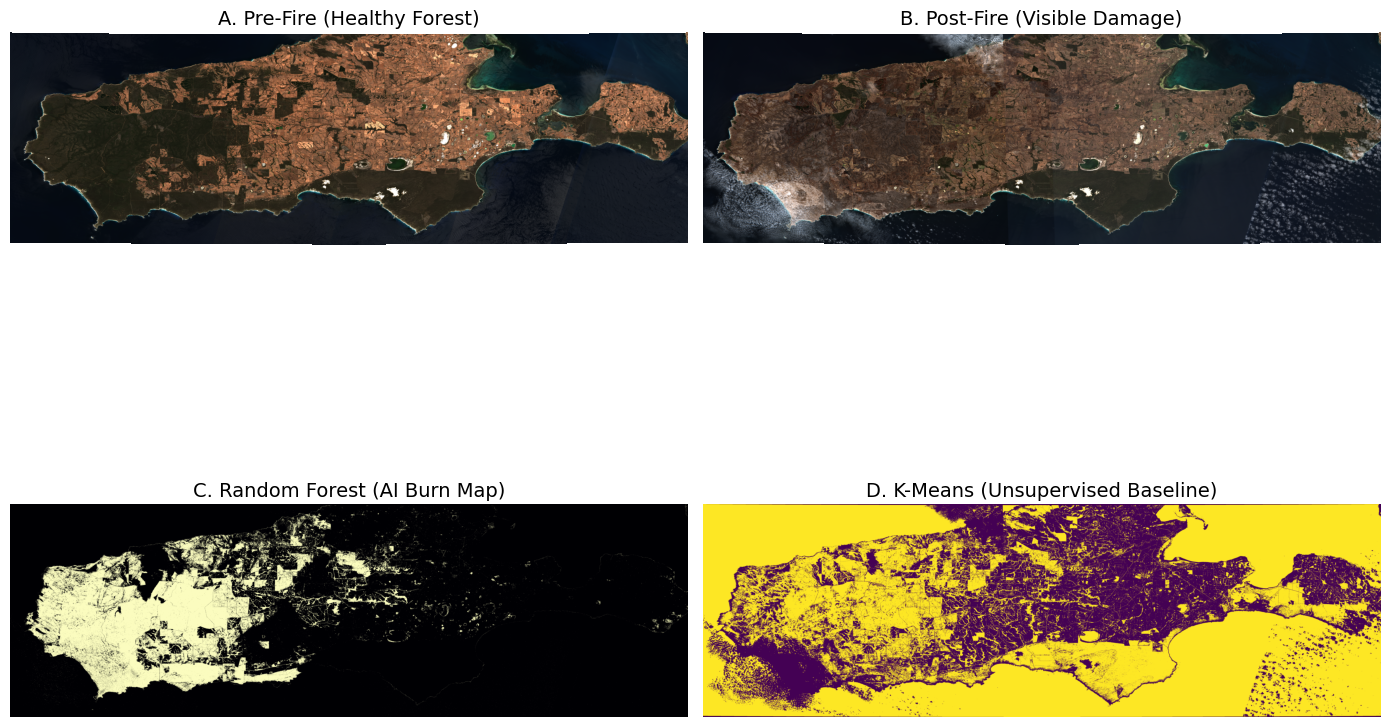

Step 12 Complete: 2x2 Comparison generated and saved.


In [21]:
#
with rasterio.open(pre_fire_path) as src:
    pre_img = src.read([1, 2, 3]).astype('float32')

# 2. Create a 2x2 Grid
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

# --- Row 1: The Raw Data ---
# Pre-Fire
ax1.imshow(np.clip(pre_img.transpose(1, 2, 0) / 3000, 0, 1))
ax1.set_title("A. Pre-Fire (Healthy Forest)", fontsize=14)
ax1.axis('off')

# Post-Fire
ax2.imshow(np.clip(full_img[[0, 1, 2]].transpose(1, 2, 0) / 3000, 0, 1))
ax2.set_title("B. Post-Fire (Visible Damage)", fontsize=14)
ax2.axis('off')

# --- Row 2: The AI Analysis ---
# Random Forest
ax3.imshow(visible_map, cmap='magma')
ax3.set_title("C. Random Forest (AI Burn Map)", fontsize=14)
ax3.axis('off')

# K-Means
ax4.imshow(kmeans_map, cmap='viridis')
ax4.set_title("D. K-Means (Unsupervised Baseline)", fontsize=14)
ax4.axis('off')

# 3. Final Polish
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'Final_2x2_Comparison.png'))
plt.show()

print("Step 12 Complete: 2x2 Comparison generated and saved.")

## Assess Environmental Impact for Notebook 3

In [ ]:
# 1. Stop the tracker and get the metrics
emissions_kg = tracker.stop()
# CodeCarbon tracks energy in kWh; we'll display that too
energy_kwh = tracker.final_emissions_data.energy_consumed

# 2. Display the detailed 3-line report
print(f"{'='*45}")
print(f"NOTEBOOK 3: FINAL ENVIRONMENTAL REPORT")
print(f"Total CO2 Emissions: {emissions_kg:.6f} kg CO2")
print(f"Energy & Water: {energy_kwh:.6f} kWh | 0.000000 L")
print(f"Status: AI Training complete and recorded.")
print(f"{'='*45}")

NOTEBOOK 3: FINAL ENVIRONMENTAL REPORT
Total CO2 Emissions: 0.068158 kg CO2
Energy & Water: 0.092334 kWh | 0.000000 L
Status: AI Training complete and recorded.
